# Point statistics

The `ps` (point statistics) module provides metrics to compare the mean spatial distribution of transcripts in relation to the centroid and the segmented outline of the cell. The idea of this module is to provide an intuition whether transcripts are distributed unequally, meaning they are more likely to have resulted from a spillover from neighbouring cells. The computed values can either be returned as a dictionary or stored in place in the `spatialdata` object.

**NOTE:** these metrics are still under active development and will change in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [1]:
%load_ext autoreload
%autoreload 2

#### Run the two metrics one at a time

In [2]:
import spatialdata as sd

import segtraq

# Load spatial transcriptomics dataset and initalize SegTraQ object
sdata = sd.read_zarr("../../data/xenium.zarr")
# only looking at a subset for visualization purposes
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h
sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
st = segtraq.SegTraQ(sdata, images_key="image", labels_to_cell_id_key="label_id")

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: Fut

The first metric we compute is the comparison of the centroid coordinate with the mean coordinate of the transcripts. This metric runs per transcript ID, which has to be passed to the function. We compute the euclidean distance between the mean coordinate per transcript $\mu_{x,y}$ with the cell centroid coordinate $cc_{x,y}$ normalised by the cell area $|C|$. The normalisation by cell area is necessary because the computed euclidean distance scales with the cell area.

$$
d_{centroid-mean} = \frac{\sqrt{cc_{x,y}^2-\mu_{x,y}^2}}{|C|}
$$

In [3]:
st.ps.centroid_mean_coord_diff("ERBB2")

,cell_id,centroid_x,x,centroid_y,y,distance,cell_area,distance_ERBB2
0,apheleok-1,985.778158,985.089111,1191.758907,1192.134766,292.053855,43.666095,6.688344
1,aphidfcb-1,847.440346,846.534424,1204.523379,1199.822266,502.323709,45.020783,11.157596
2,aphjeaih-1,896.008961,896.242737,1176.362067,1175.994141,396.053709,144.409693,2.742570
3,aphjibjb-1,902.717059,903.323486,1185.087632,1185.001953,398.843071,162.562506,2.453475
4,aphjipcp-1,906.175978,907.237549,1173.395138,1175.572266,378.700703,83.539066,4.533217
...,...,...,...,...,...,...,...,...
72,ipocgjja-1,914.824386,910.706299,1191.846922,1193.259766,395.684610,102.007972,3.878958
73,ipocjkfn-1,949.063130,952.190674,1154.533621,1152.166016,286.694002,101.059691,2.836878
74,ipoclfbi-1,967.669438,968.940674,1150.176639,1151.947266,258.466231,98.124535,2.634063
75,jaadeldi-1,927.709138,927.526611,1357.700496,1353.712891,605.416194,137.455630,4.404448


This result is also stored in `spatialdata` object and accesible in the observations of the `anndata` component.

In [4]:
sdata["table"].obs[sdata["table"].obs["distance_ERBB2"].notna()].head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,label_id,region,distance_ERBB2
6,apheleok-1,985.953428,1191.931367,121,0,0,0,0,21,142,43.666095,25.287501,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3804,cell_labels,6.688344
27,aphidfcb-1,847.619199,1204.688203,99,0,1,0,0,27,127,45.020783,18.649532,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3846,cell_labels,11.157596
33,aphjeaih-1,896.131162,1176.530000,452,0,0,0,0,106,558,144.409693,102.865941,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3852,cell_labels,2.742570
37,aphjibjb-1,902.833555,1185.372773,440,0,0,0,0,78,518,162.562506,68.502034,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3856,cell_labels,2.453475
38,aphjipcp-1,906.314512,1173.572969,265,0,0,0,0,44,309,83.539066,58.657971,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3857,cell_labels,4.533217


We can visualise these results in space for the gene ERBB2

In [5]:
import spatialdata_plot as sdata_plot

gene_name = "ERBB2"

In [6]:
import copy

sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_ERBB2"].notna()]

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


In [7]:
# link annotations with cell boundaries
sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries")

/tmp/ipykernel_30836/3780718550.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", Implici

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:775: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/render.py:682: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(


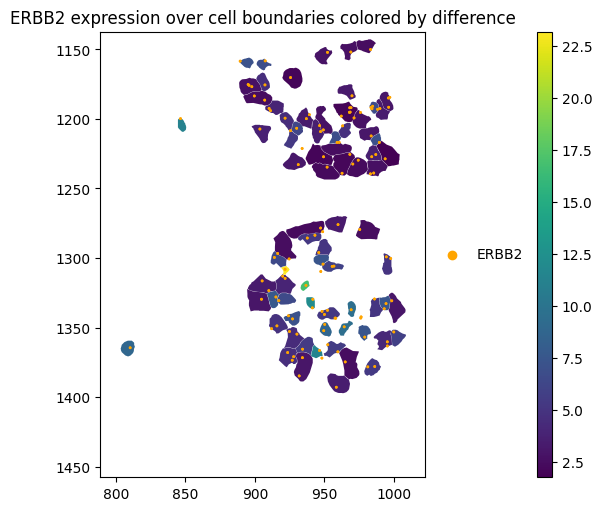

In [8]:
sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="distance_ERBB2",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name,
    palette="orange",
).pl.show(
    title=f"{gene_name} expression over cell boundaries colored by difference",
    coordinate_systems="global",
    figsize=(10, 5),
)

We notice that there are some cells with a lot of cells at the boundary and some others that are more balanced

The other metric implemented on the transcript coordinate level is the comparison of the transcript locations in relation to the distance to the membrane. In some sense, this is complementary to the `centroid_mean_coord_diff` metric. However, in the case of very irregularly shaped cells, the distance to the membrane is a more direct measure of unequal transcript distribution and hence potential spillover.  

The metric is defined as the mean distance to the cell membrane $\mu(d(m,t))$ (as provided in the `spatialdata` object) divided by the cell area $|C|$.

$$
d_{membrane} = \frac{\mu(d(m,t))}{|C|}
$$

In [9]:
st.ps.distance_to_membrane("ERBB2")

,cell_id,distance_to_outline_ERBB2,cell_area,distance_to_outline_inverse_ERBB2
0,apheleok-1,1.002028,43.666095,0.998988
1,aphidfcb-1,0.046875,45.020783,4.618802
2,aphjeaih-1,4.259394,144.409693,0.484536
3,aphjibjb-1,3.361656,162.562506,0.545410
4,aphjipcp-1,3.252922,83.539066,0.554451
...,...,...,...,...
72,ipocgjja-1,1.651899,102.007972,0.778051
73,ipocjkfn-1,1.841699,101.059691,0.736870
74,ipoclfbi-1,1.104993,98.124535,0.951306
75,jaadeldi-1,1.513872,137.455630,0.812747
